## Decision Tree Classification

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.describe()
# titanic.info()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [5]:
# fill missing data

from sklearn.impute import SimpleImputer
imp_median =SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic.shape

(891, 15)

In [8]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [10]:
X = titanic[features]
y = titanic[target]

In [11]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [12]:
# Train-Test-Split

X_train,X_test,y_train,y_test = train_test_split(
    X, y,test_size=0.3, random_state=42
)

In [13]:
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


## Decision Tree Model
- No prunning

In [14]:
# Decision Tree Model - no prunning

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy Score:" ,accuracy_score(y_test,y_pred))

Accuracy Score: 0.7611940298507462


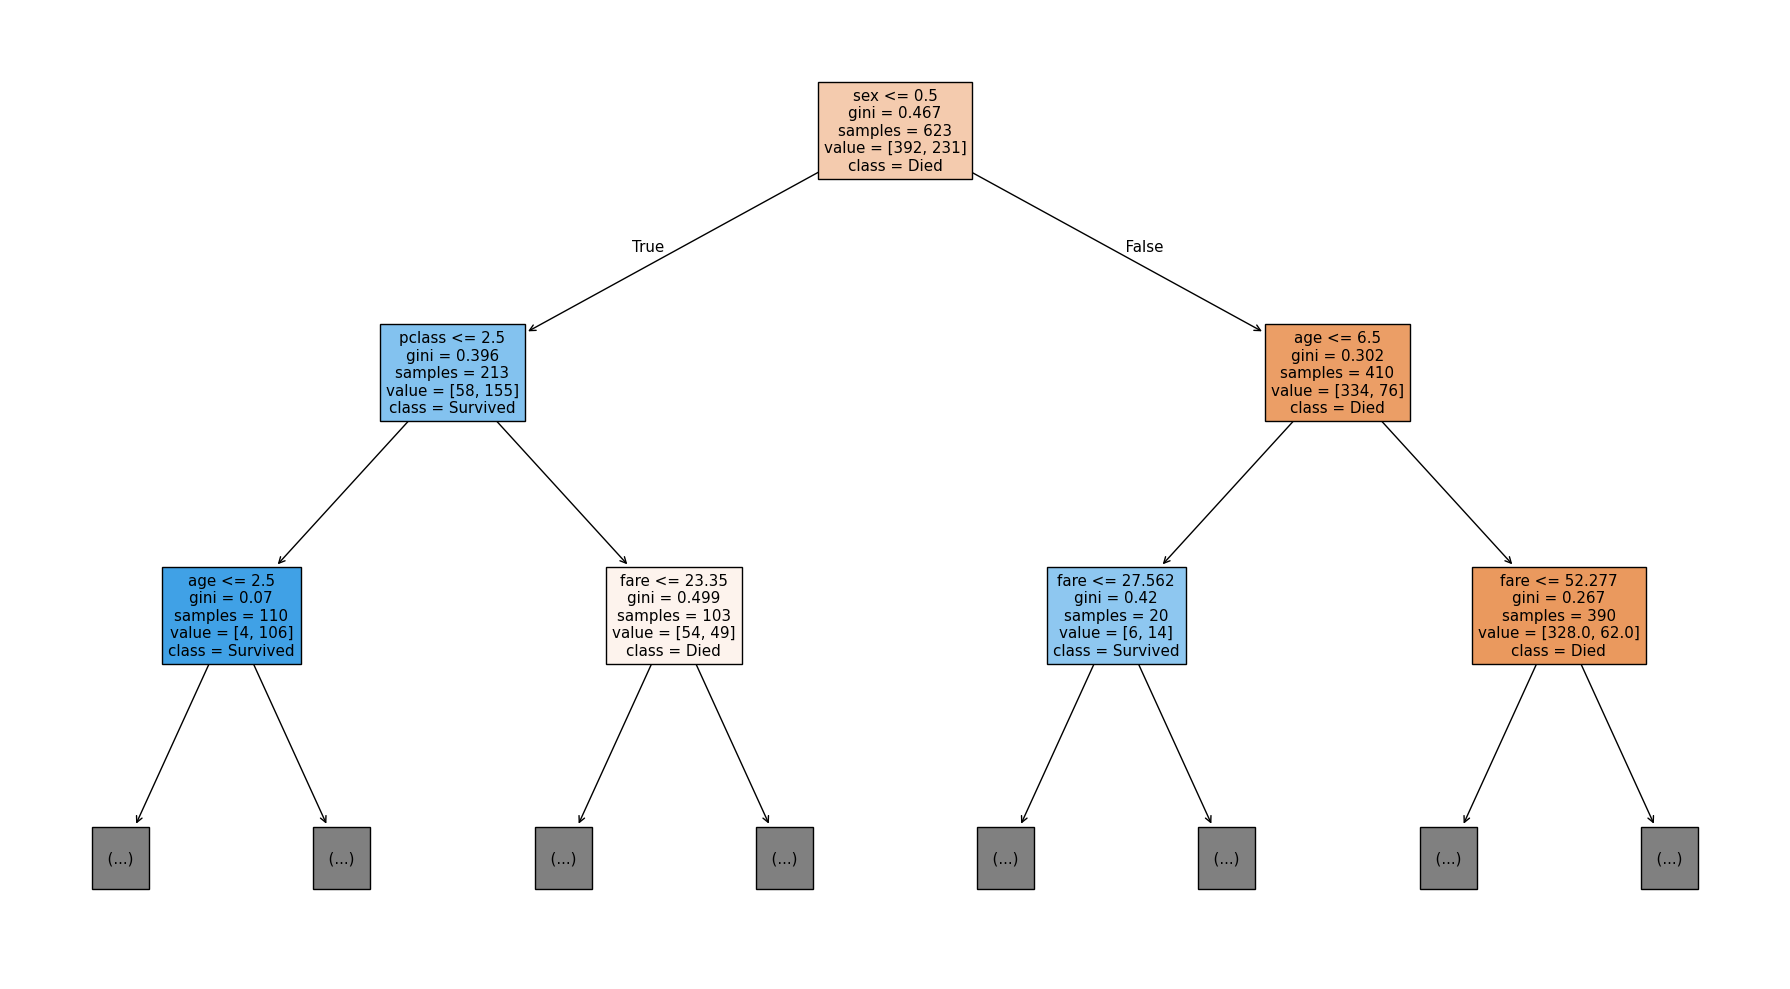

In [16]:
#Plot Tree

from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],  #0 = died, 1 = survived
    filled = True,
    max_depth=2
)
plt.tight_layout()
plt.show()


## Decision Tree with pre-prunning

for depth = 2 , accuracy =0.7723880597014925
for depth = 3 , accuracy =0.8059701492537313
for depth = 4 , accuracy =0.8246268656716418


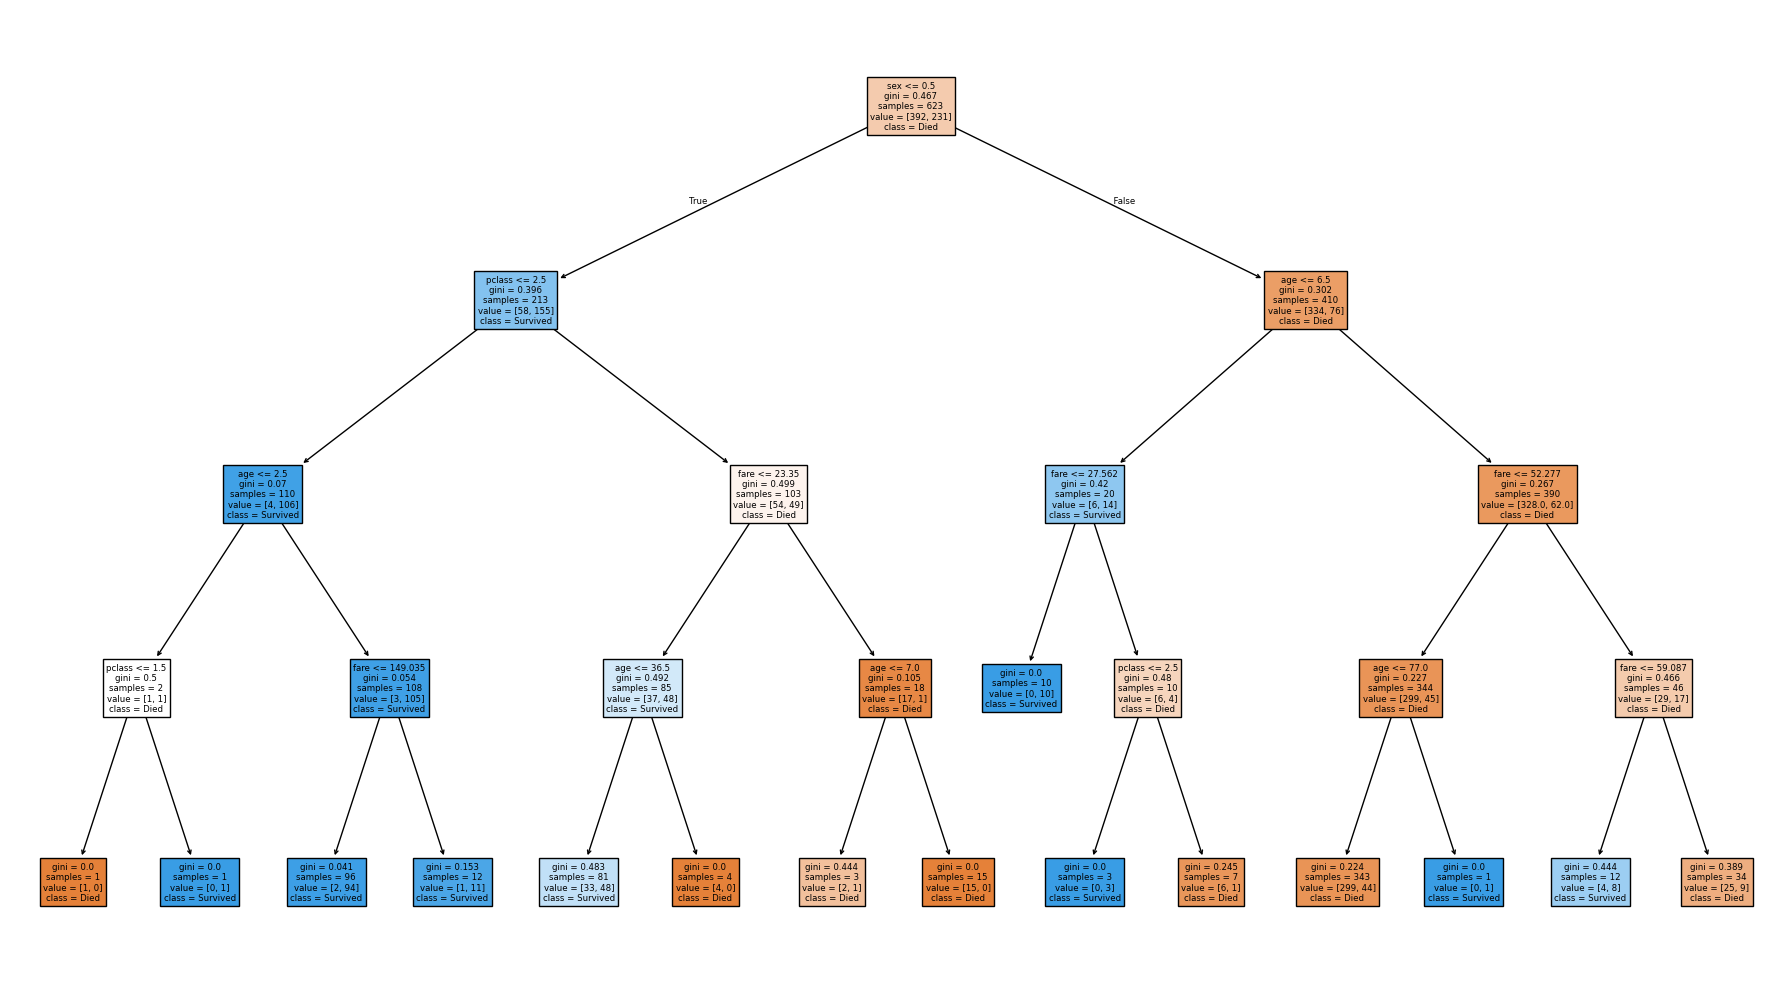

for depth = 5 , accuracy =0.7947761194029851
for depth = 6 , accuracy =0.7873134328358209
for depth = 7 , accuracy =0.7761194029850746
for depth = 8 , accuracy =0.7947761194029851
for depth = 9 , accuracy =0.7835820895522388
for depth = 10 , accuracy =0.7835820895522388


In [17]:
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for depth = {depth} , accuracy ={acc}")

    if depth==4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True
        )
        plt.tight_layout()
        plt.show()
    
    

for sample split = 5 , accuracy =0.8246268656716418
for sample split = 10 , accuracy =0.8246268656716418


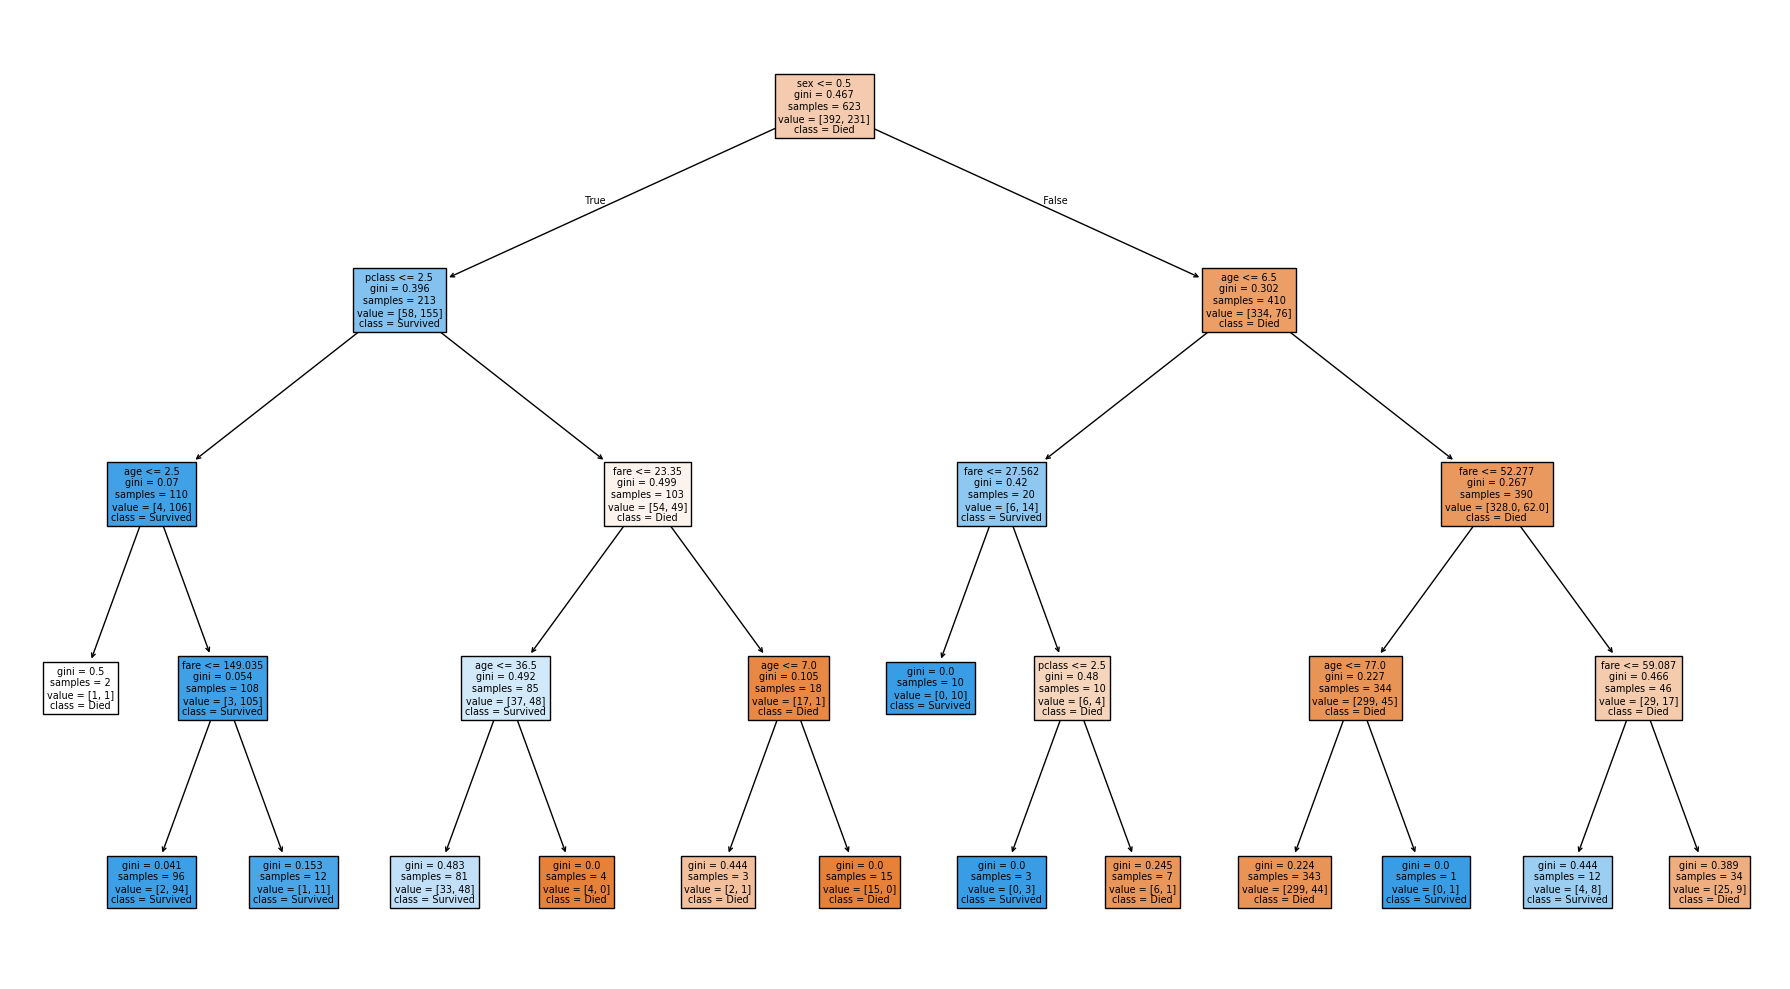

for sample split = 15 , accuracy =0.8171641791044776
for sample split = 20 , accuracy =0.8171641791044776
for sample split = 25 , accuracy =0.8208955223880597
for sample split = 30 , accuracy =0.8208955223880597


In [18]:
min_samples_split = [5,10,15,20,25,30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth = 4,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for sample split = {split} , accuracy ={acc}")

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True
        )
        plt.tight_layout()
        plt.show()

## Decision Tree with post-prunning

In [19]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [21]:
# train our model for all alphas
trees =[]
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha = alpha)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)

    trees.append((model,alpha))

In [22]:
best_acc = 0
best_alpha = 0

for model , alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [23]:
print(best_alpha)
print(best_acc)

0.0017121455323702516
0.8208955223880597


In [24]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


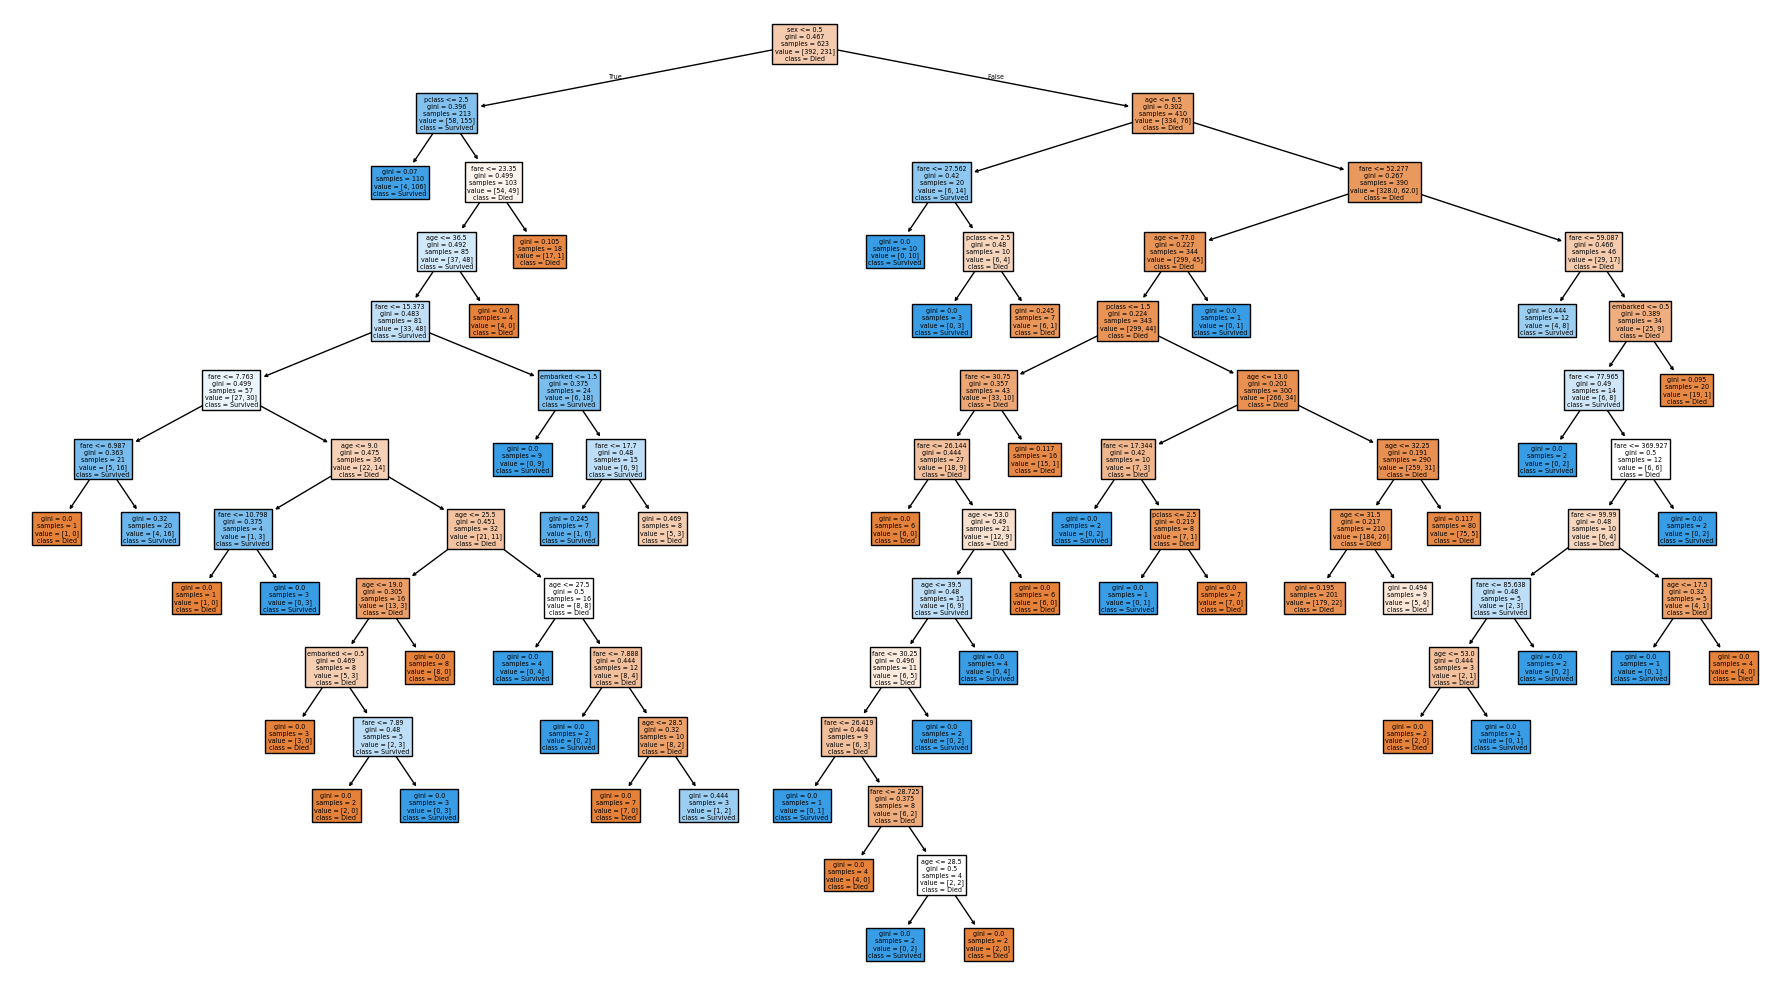

In [25]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)
plt.tight_layout()
plt.show()

In [26]:
print(best_model.score(X_test,y_test))

0.8171641791044776


## Decision Tree with both combination of Preprunning+postprunning

In [27]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


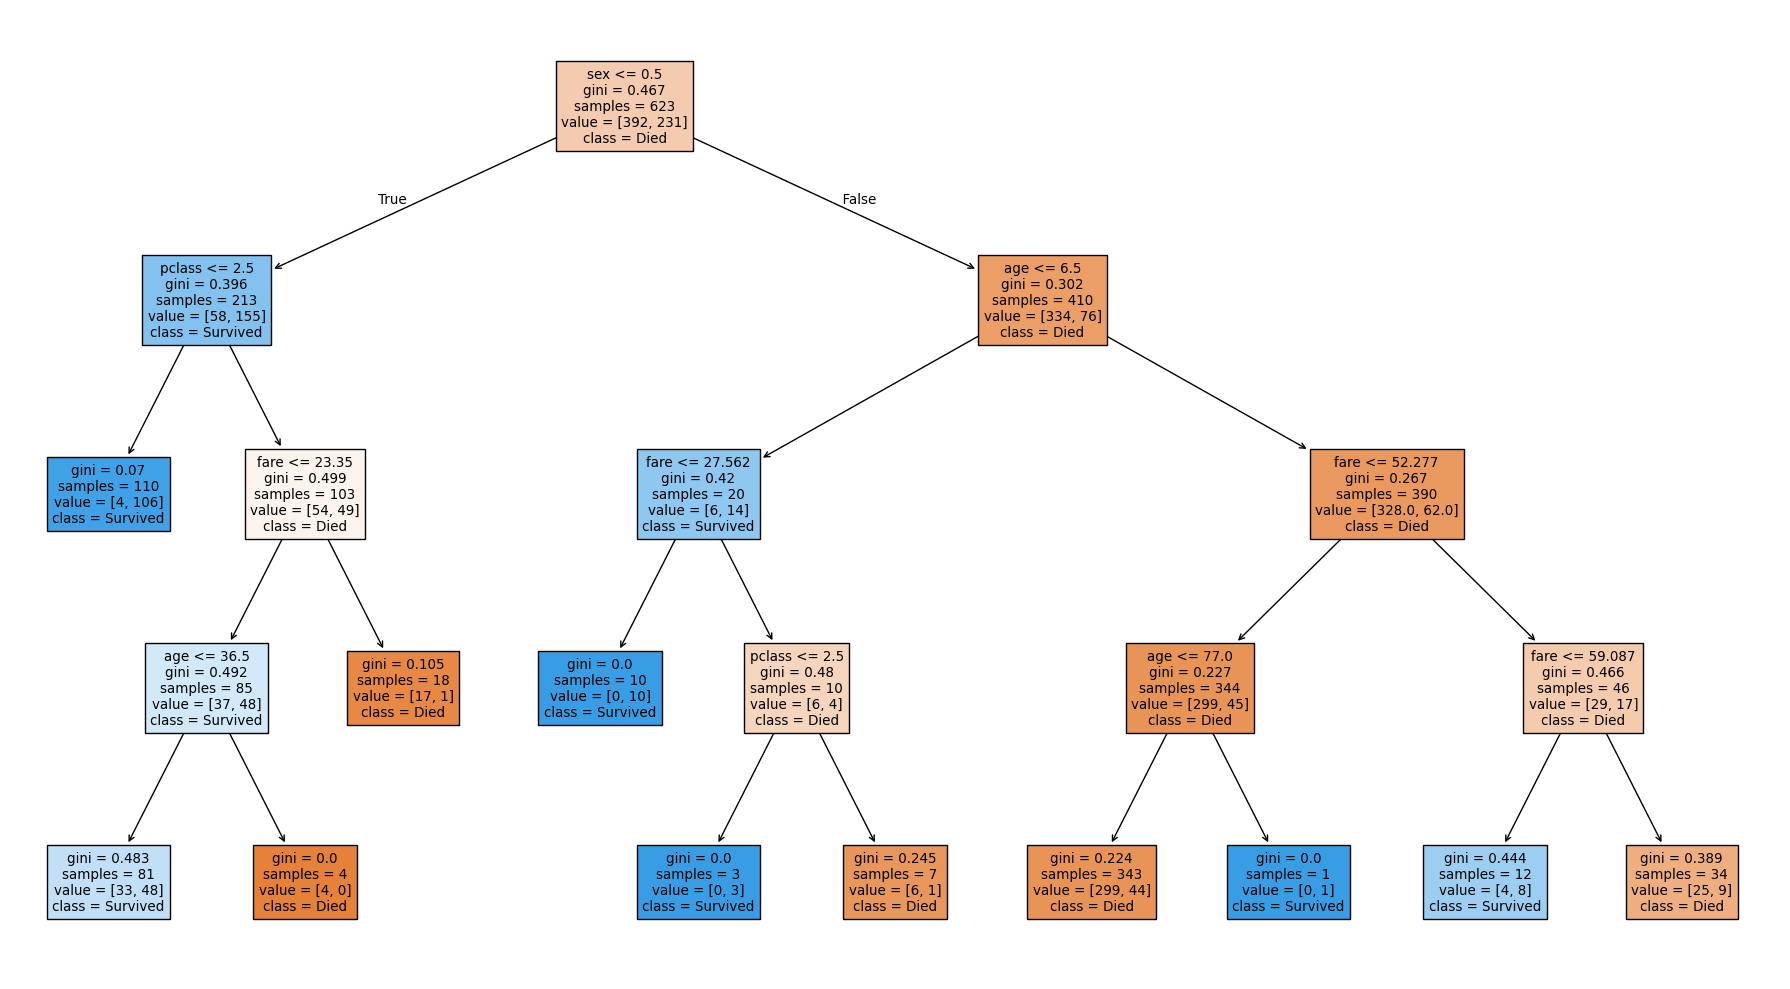

In [28]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)
plt.tight_layout()
plt.show()

In [29]:
print(best_model.score(X_test,y_test))

0.8246268656716418
